In [1]:
import numpy as np
import torch
import geoopt
import h5py

In [4]:
import h5py

# /n/holystore01/LABS/iaifi_lab/Lab/nswood/hyperbolic_gaussians_toy_updated/train/train_1.h5
data_file = '/n/holystore01/LABS/iaifi_lab/Lab/nswood/hyperbolic_gaussians_toy_updated/train/train_1.h5'
with h5py.File(data_file, 'r') as cur_file:
    cur_data = cur_file['datasets'][:]
    cur_labels = cur_file['labels'][:]
    cur_graph_dist_matrices= cur_file['graph_dist_matrices'][:]
    print(cur_data[0])
    print(cur_labels[0])
    print(cur_graph_dist_matrices[0])

[[ 2.13394258e-02  3.84598039e-02]
 [ 2.02045351e-01  3.25890034e-01]
 [ 6.32956848e-02 -3.31821889e-02]
 [-8.31477493e-02 -9.45951194e-02]
 [ 1.10294849e-01  2.34488696e-01]
 [ 2.93879751e-02 -7.91129544e-02]
 [-1.15374669e-01 -7.76344091e-02]
 [ 2.81398207e-01  1.92054398e-02]
 [ 2.97454298e-01  3.67832601e-01]
 [ 1.55944914e-01  1.80536851e-01]
 [-2.29682848e-02 -9.81643870e-02]
 [-1.54708624e-01 -1.92151740e-01]
 [-1.01273105e-01  4.80189547e-02]
 [ 1.90822020e-01 -1.62840426e-01]
 [-1.32627031e-02 -5.96776679e-02]
 [ 1.15277283e-02 -5.74539453e-02]
 [ 2.83197612e-01  3.49903524e-01]
 [-2.20865402e-02 -1.06106205e-02]
 [-4.32983525e-02 -1.27570242e-01]
 [ 3.49177904e-02 -9.40413475e-02]
 [-1.51702454e-02 -2.08055750e-01]
 [-8.44062306e-03 -1.55020162e-01]
 [ 1.47269741e-02  8.26623931e-04]
 [-3.01276799e-03  7.55844265e-03]
 [ 2.24524885e-02 -1.41753748e-01]
 [-3.06282192e-02  7.73585401e-04]
 [-9.82978344e-02 -1.21223733e-01]
 [ 2.70639956e-01  2.25165457e-01]
 [ 6.30859360e-02 -1

In [4]:

def manifold_gaussian_pdf(x, mean, std, manifold):
    """
    Compute the probability density of a point x under a manifold Gaussian.
    """
    d = manifold.dist(torch.tensor(x), mean)  # Compute manifold distance
    return np.exp(-d**2 / (2 * std**2))  # Gaussian decay in manifold space

def sample_manifold_gaussian(n_samples, mean, variance, manifold, max_attempts=50000):
    """
    Sample from a manifold Gaussian using rejection sampling.
    
    Parameters:
    - n_samples (int): Number of points to sample.
    - mean (np.ndarray): Mean point in the manifold (shape: (2,))
    - std (float): Standard deviation in manifold space.
    - max_attempts (int): Maximum number of attempts before giving up.

    Returns:
    - np.ndarray: Sampled points in the manifold (shape: (n_samples, 2)).
    """
    samples = []
    attempts = 0
    
    while len(samples) < n_samples and attempts < max_attempts:
        # Propose a random point in the manifold
        radius = np.random.uniform(0,1/np.sqrt(np.abs(manifold.k)))
        theta = np.random.uniform(0, 2*np.pi)
        x = radius*np.array([np.cos(theta), np.sin(theta)])

        # Compute acceptance probability
        prob = manifold_gaussian_pdf(x, mean, variance,manifold)
        threshold = np.random.uniform(0, 1)  # Random uniform value

        if prob > threshold:  # Accept if it follows the Gaussian distribution
            samples.append(x)

        attempts += 1

    if len(samples) < n_samples:
        print("Warning: Could not generate enough points within max_attempts.")

    return torch.tensor(samples)

In [ ]:

# Define the manifold manifold (Poincaré Ball)
manifold = geoopt.PoincareBall(c=1)  # Curvature c=1
radius = manifold.radius
# Step 1: Sample 4 centroids from a zero-mean manifold Gaussian (variance 1.5)
mean_zero = torch.zeros(2)  # Center at origin
centroid_var = 1 * radius.numpy()  
n_centroids = 4 
centroids = sample_manifold_gaussian(n_samples=n_centroids, mean=mean_zero, variance=centroid_var, manifold=manifold)

# Step 2: Sample 100 points around each centroid (unit variance)
dataset = []
tan_dataset = []
labels = []
c_labels =[]
num_sampels = 100

# Variable variance for each cluster 
var_percents = np.random.uniform(0.15, 0.5, n_centroids) 

# Define the variance according to the radius of the space for realistic clusters
vars = var_percents * radius.numpy()
for i, centroid in enumerate(centroids):
    points = sample_manifold_gaussian(n_samples=num_sampels, mean=centroid, variance=vars[i], manifold=manifold)
    dataset.append(points)
    # tan_dataset.append(manifold.logmap(points, centroid)+manifold.logmap0(centroid))
    tan_dataset.append(manifold.logmap0(points))

    
    labels.extend([i] * len(points))  # Assign class labels
    c_labels.append(i)

# Convert to NumPy
dataset = torch.cat(dataset).numpy()
tan_dataset = torch.cat(tan_dataset).numpy()
labels = np.array(labels)

tan_centroids = manifold.logmap0(centroids)


In [ ]:
import matplotlib.pyplot as plt

color_map = plt.cm.get_cmap('viridis', len(centroids))
fig, ax = plt.subplots(figsize=(6,6))
ax.add_patch(plt.Circle((0, 0), radius, color='black', fill=False))  # manifold boundary
scatter = plt.scatter(dataset[:, 0], dataset[:, 1], c=labels, cmap='viridis', alpha=0.2)
for i, centroid in enumerate(centroids):
    plt.scatter(centroid[0], centroid[1], color=color_map(c_labels[i]), marker='x', s=200, linewidths=5, label=f"Centroid {i}: Var: {vars[i]:.2f}")
    
plt.xlim(-radius, radius)
plt.ylim(-radius, radius)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("manifold Gaussian Mixture in manifold")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize = 12)
plt.show()


fig, ax = plt.subplots(figsize=(6,6))
scatter = plt.scatter(tan_dataset[:, 0], tan_dataset[:, 1], c=labels, cmap='viridis', alpha=0.1)
# plt.scatter(tan_centroids[:, 0], tan_centroids[:, 1], c=c_labels, marker='x', s=200, linewidths= 5, label="Centroids")
for i, tan_centroid in enumerate(tan_centroids):
    plt.scatter(tan_centroid[0], tan_centroid[1], color=color_map(c_labels[i]), marker='x', s=200, linewidths=5, label=f"Centroid {i}: Var: {vars[i]:.2f}")

plt.gca().set_aspect('equal', adjustable='box')
plt.title("manifold Gaussian Mixture in manifold")
plt.show()

tan_data_mapped_back = manifold.expmap0(torch.tensor(tan_dataset)).numpy()
fig, ax = plt.subplots(figsize=(6,6))
ax.add_patch(plt.Circle((0, 0), radius, color='black', fill=False))  # manifold boundary
scatter = plt.scatter(tan_data_mapped_back[:, 0], tan_data_mapped_back[:, 1], c=labels, cmap='viridis', alpha=0.2)
for i, centroid in enumerate(centroids):
    plt.scatter(centroid[0], centroid[1], color=color_map(c_labels[i]), marker='x', s=200, linewidths=5, label=f"Centroid {i}: Var: {vars[i]:.2f}")
    
plt.xlim(-radius, radius)
plt.ylim(-radius, radius)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("tan_0 dataset mapped back onto manifold")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize = 12)
plt.show()


In [15]:
import glob
import numpy as np
import pandas as pd

log_dir = '/n/home11/nswood/particle_transformer/gaussian_classification_final_model'
files = glob.glob(log_dir + '/*/log.csv')


data = []

for f in files: 
    name = f.split('/')[-2].split('run_')[-1]
    dim = int(name.split('_')[1])
    df = pd.read_csv(f)
    params_file = f.replace('log.csv', 'model_parameters.csv')
    params = pd.read_csv(params_file)['Value'].iloc[0]
    best_acc = df['Val Accuracy'].max()
    if np.isnan(best_acc):
        continue
    data.append((name, best_acc,params))
    
data = np.array(data)


# Extract dimension, geometry, and features from the names
model_info = []
for name, acc, params in data:
    parts = name.split('_')
    n_parts = len(parts[0].split('x'))
    name = name.split('_2025')[0]
    

    dim = n_parts * int(parts[1])  # Dimension is the second part of the name
    
    model_info.append((name, dim, acc, params, parts[0]))
    

# Convert to DataFrame for easier manipulation
model_info_df = pd.DataFrame(model_info, columns=['Name', 'Dimension', 'Accuracy', 'Params', 'Geometry'])
# Group by 'Name' and take the max 'Accuracy' for repeated names
model_info_df = model_info_df.groupby('Name').agg({'Dimension': 'first', 'Accuracy': 'max', 'Params': 'first', 'Geometry':'first'}).reset_index()


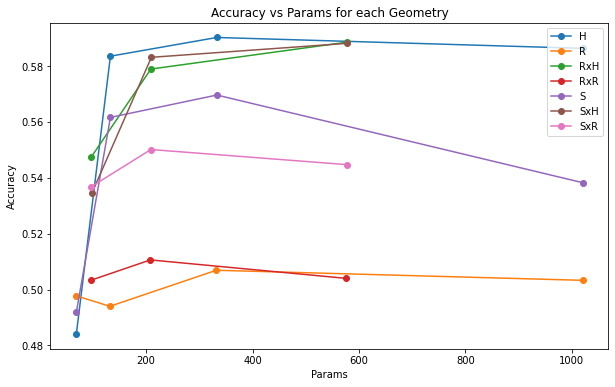

In [16]:
import matplotlib.pyplot as plt

# Convert Accuracy and Params to numeric types
model_info_df['Accuracy'] = pd.to_numeric(model_info_df['Accuracy'])
model_info_df['Params'] = pd.to_numeric(model_info_df['Params'])

# Get unique geometries
unique_geometries = model_info_df['Geometry'].unique()
plt.figure(figsize=(10, 6))
# Plot for each geometry
for geom in unique_geometries:
    geom_data = model_info_df[model_info_df['Geometry'] == geom]
    geom_data = geom_data.sort_values(by='Params')
    param_filter = geom_data['Params'] < 1500
    
    
    geom_data = geom_data[param_filter]

    

    plt.plot(geom_data['Params'], geom_data['Accuracy'], marker='o', label=geom)

plt.xlabel('Params')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Params for each Geometry')
plt.legend()
plt.show()

In [1]:
import glob
import numpy as np
import pandas as pd

log_dir = '/n/home11/nswood/particle_transformer/gaussian_classification_final_model_higher_reg'
files = glob.glob(log_dir + '/*/log.csv')

data = []

for f in files: 
    name = f.split('/')[-2].split('run_')[-1]
    dim = int(name.split('_')[1])
    df = pd.read_csv(f)
    params_file = f.replace('log.csv', 'model_parameters.csv')
    params = pd.read_csv(params_file)['Value'].iloc[0]
    best_acc = df['Val Accuracy'].max()
    if np.isnan(best_acc):
        continue
    data.append((name, best_acc,params))
    
data = np.array(data)


# Extract dimension, geometry, and features from the names
model_info = []
for name, acc, params in data:
    parts = name.split('_')
    n_parts = len(parts[0].split('x'))
    name = name.split('_2025')[0]
    

    dim = n_parts * int(parts[1])  # Dimension is the second part of the name
    lr = name.split('_')[-2]
    batch = name.split('_')[-1]
    model_info.append((name, dim, acc, params, parts[0], lr, batch))
    

# Convert to DataFrame for easier manipulation
model_info_df = pd.DataFrame(model_info, columns=['Name', 'Dimension', 'Accuracy', 'Params', 'Geometry', 'Learning Rate','Batch'])
# Group by 'Name' and take the max 'Accuracy' for repeated names
model_info_df = model_info_df.groupby('Name').agg({'Dimension': 'first', 'Accuracy': 'max', 'Params': 'first', 'Geometry':'first','Learning Rate':'first','Batch':'first'}).reset_index()
model_info_df = model_info_df.groupby(['Geometry', 'Dimension']).agg({'Accuracy': 'max', 'Params': 'first', 'Learning Rate': 'first','Batch':'first'}).reset_index()

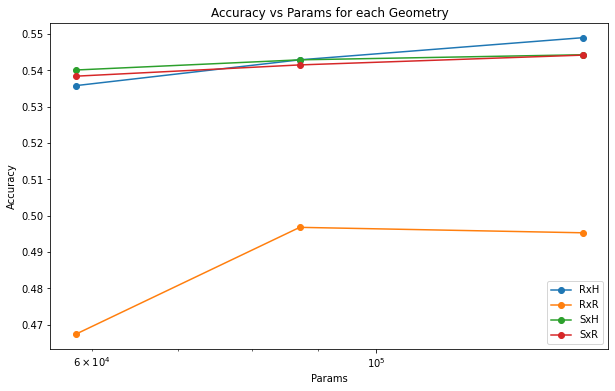

In [10]:
import matplotlib.pyplot as plt

# Convert Accuracy and Params to numeric types
model_info_df['Accuracy'] = pd.to_numeric(model_info_df['Accuracy'])
model_info_df['Params'] = pd.to_numeric(model_info_df['Params'])

# Get unique geometries
unique_geometries = model_info_df['Geometry'].unique()
plt.figure(figsize=(10, 6),facecolor = 'w')
# Plot for each geometry
for geom in unique_geometries:
    if len(geom) > 1:
        geom_data = model_info_df[model_info_df['Geometry'] == geom]
        geom_data = geom_data.sort_values(by='Params')
        # param_filter = geom_data['Params'] < 1500
        # geom_data = geom_data[param_filter]
        plt.plot(geom_data['Params'], geom_data['Accuracy'], marker='o', label=geom)

plt.xlabel('Params')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Params for each Geometry')
plt.xscale('log')
plt.legend()
plt.show()

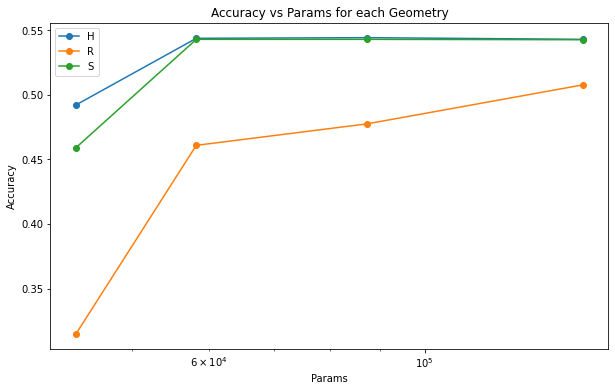

In [9]:
import matplotlib.pyplot as plt

# Convert Accuracy and Params to numeric types
model_info_df['Accuracy'] = pd.to_numeric(model_info_df['Accuracy'])
model_info_df['Params'] = pd.to_numeric(model_info_df['Params'])

# Get unique geometries
unique_geometries = model_info_df['Geometry'].unique()
plt.figure(figsize=(10, 6), facecolor='w')
# Plot for each geometry
for geom in unique_geometries:
    if len(geom) == 1:
        geom_data = model_info_df[model_info_df['Geometry'] == geom]
        geom_data = geom_data.sort_values(by='Params')
        # param_filter = geom_data['Params'] < 1500
        # geom_data = geom_data[param_filter]
        plt.plot(geom_data['Params'], geom_data['Accuracy'], marker='o', label=geom)

plt.xlabel('Params')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Params for each Geometry')
plt.xscale('log')
plt.legend()
plt.show()

In [5]:
import glob
import numpy as np
import pandas as pd

log_dir = '/n/home11/nswood/particle_transformer/gaussian_classification_learnable_curvature_lower_lr'
files = glob.glob(log_dir + '/*/log.csv')
data = []

for f in files: 
    name = f.split('/')[-2].split('run_')[-1]
    dim = int(name.split('_')[1])
    df = pd.read_csv(f)
    params_file = f.replace('log.csv', 'model_parameters.csv')
    params = pd.read_csv(params_file)['Value'].iloc[0]
    best_acc = df['Val Accuracy'].max()
    all_curvatures = df['Curvature']
    if np.isnan(best_acc):
        continue
    data.append((name, best_acc,params))
    
data = np.array(data)


# Extract dimension, geometry, and features from the names
model_info = []
for name, acc, params in data:
    parts = name.split('_')
    n_parts = len(parts[0].split('x'))
    name = name.split('_2025')[0]
    

    dim = n_parts * int(parts[1])  # Dimension is the second part of the name
    
    model_info.append((name, dim, acc, params, parts[0],parts[2]))
    

# Convert to DataFrame for easier manipulation
model_info_df = pd.DataFrame(model_info, columns=['Name', 'Dimension', 'Accuracy', 'Params', 'Geometry','Curvature'])
# Group by 'Name' and take the max 'Accuracy' for repeated names
model_info_df = model_info_df.groupby('Name').agg({'Dimension': 'first', 'Accuracy': 'max', 'Params': 'first', 'Geometry':'first','Curvature':'first'}).reset_index()

# Get unique dimensions
unique_dims = model_info_df['Dimension'].unique()
unique_dims = np.sort(unique_dims)

# Print the order of models sorted by best performing for each dimension
for dim in unique_dims:
    
    sorted_models = model_info_df[model_info_df['Dimension'] == dim].sort_values(by='Accuracy', ascending=False)
    print(f"Dimension: {dim}")
    for _, model in sorted_models.iterrows():
        geom = model['Name'].split('_')[0]
        dim = model['Name'].split('_')[1]
        print(f"Model: {model['Name']}, Accuracy: {model['Accuracy']}, Params: {model['Params']}, Geom {model['Geometry']}")
    print()


KeyError: 'Curvature'

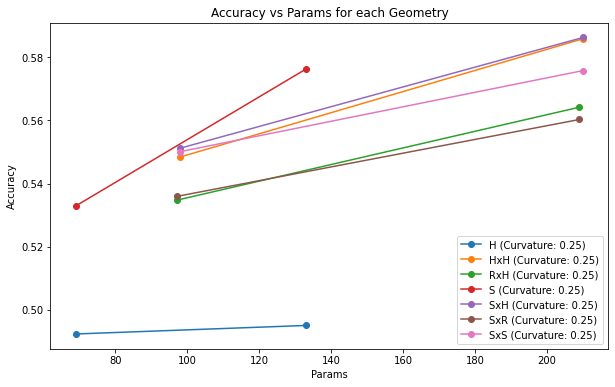

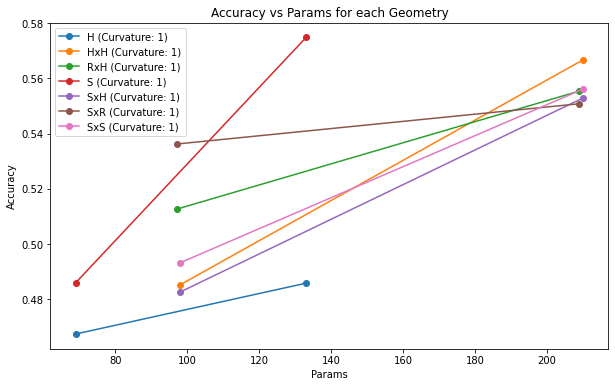

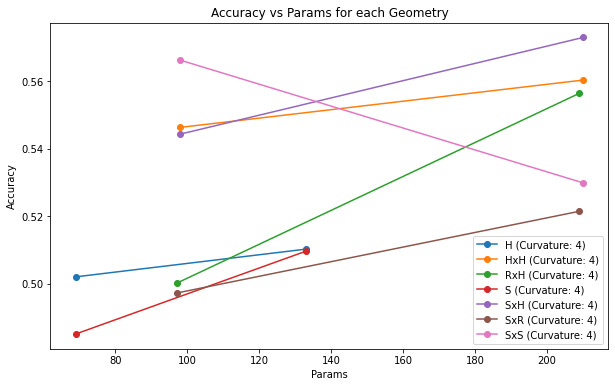

In [7]:
import matplotlib.pyplot as plt

# Convert Accuracy and Params to numeric types
model_info_df['Accuracy'] = pd.to_numeric(model_info_df['Accuracy'])
model_info_df['Params'] = pd.to_numeric(model_info_df['Params'])

# Get unique geometries
unique_geometries = model_info_df['Geometry'].unique()
unique_curvatures = model_info_df['Curvature'].unique()

# Plot for each geometry
for curv in unique_curvatures:
    plt.figure(figsize=(10, 6))
    for geom in unique_geometries:
        geom_curv_data = model_info_df[(model_info_df['Geometry'] == geom) & (model_info_df['Curvature'] == curv)]
        if not geom_curv_data.empty:
            geom_curv_data = geom_curv_data.sort_values(by='Params')
            plt.plot(geom_curv_data['Params'], geom_curv_data['Accuracy'], marker='o', label=f"{geom} (Curvature: {curv})")

    plt.xlabel('Params')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Params for each Geometry')
    plt.legend()
    plt.show()

In [38]:
import h5py
data_file = '/n/holystore01/LABS/iaifi_lab/Lab/nswood/hyperbolic_gaussians_toy/train/train_100.h5'
with h5py.File(data_file, 'r') as cur_file:
    # Directly convert the dataset to torch tensor to avoid extra numpy concatenation
    cur_data = cur_file['datasets'][:]
    cur_labels = cur_file['labels'][:]
    # print('Cur Data:', cur_data.shape)
    # print('Cur Labels:', cur_labels.shape)
    new_data = []
    new_labels = []
    for i in range(cur_labels.shape[0]):
        sample_data = []
        sample_labels = []
        for lbl in [0, 1, 2, 3]:
            idx = np.where(cur_labels[i] == lbl)[0][:100]
            sample_data.append(cur_data[i, idx, :])
            sample_labels.append(cur_labels[i, idx])
        sample_data = np.concatenate(sample_data, axis=0)
        sample_labels = np.concatenate(sample_labels, axis=0)
        
        perm = np.random.permutation(sample_data.shape[0])
        sample_data = sample_data[perm]
        sample_labels = sample_labels[perm]

        new_data.append(sample_data)
        new_labels.append(sample_labels)
    cur_data = np.stack(new_data, axis=0)
    cur_labels = np.stack(new_labels, axis=0)

In [6]:
cur_data = torch.tensor(cur_data)
cur_labels = torch.tensor(cur_labels)


In [ ]:
import matplotlib.pyplot as plt

plt.scatter(cur_data[0][:, 0], cur_data[0][:, 1], c=cur_labels[0], cmap='viridis', alpha=0.2)

In [ ]:
cur_labels.flatten().unique(return_counts=True)

In [7]:
import torch
data = torch.rand(256, 400, 2).double()
manifold = geoopt.PoincareBall(c=1)



In [ ]:
data.type()

In [ ]:
manifold.weighted_midpoint(data,dim=0,reducedim=[1],keepdim=True).shape

In [72]:
import geoopt
from geoopt.manifolds.stereographic.math import _lambda_x, _mobius_scalar_mul, _dist, _antipode, clamp_abs, drop_dims
from typing import List, Optional
def list_range(end: int):
    res: List[int] = []
    for d in range(end):
        res.append(d)
    return res
def _weighted_midpoint(
    xs: torch.Tensor,
    k: torch.Tensor,
    weights: Optional[torch.Tensor] = None,
    reducedim: Optional[List[int]] = None,
    dim: int = -1,
    keepdim: bool = False,
    lincomb: bool = False,
    posweight: bool = False,
):
    if reducedim is None:
        reducedim = list_range(xs.dim())
        reducedim.pop(dim)
    gamma = _lambda_x(xs, k=k, dim=dim, keepdim=True)
    if weights is None:
        weights = torch.tensor(1.0, dtype=xs.dtype, device=xs.device)
    else:
        weights = weights.unsqueeze(dim)
    if posweight and weights.lt(0).any():
        xs = torch.where(weights.lt(0), _antipode(xs, k=k, dim=dim), xs)
        weights = weights.abs()
    denominator = ((gamma - 1) * weights).sum(reducedim, keepdim=True)
    nominator = (gamma * weights * xs).sum(reducedim, keepdim=True)
    two_mean = nominator / clamp_abs(denominator, 1e-10)
    a_mean = _mobius_scalar_mul(
        torch.tensor(0.5, dtype=xs.dtype, device=xs.device), two_mean, k=k, dim=dim
    )
    if torch.any(k.gt(0)):
        # check antipode
        b_mean = _antipode(a_mean, k, dim=dim)
        a_dist = _dist(a_mean, xs, k=k, keepdim=True, dim=dim).sum(
            reducedim, keepdim=True
        )
        b_dist = _dist(b_mean, xs, k=k, keepdim=True, dim=dim).sum(
            reducedim, keepdim=True
        )
        better = k.gt(0) & (b_dist < a_dist)
        a_mean = torch.where(better, b_mean, a_mean)
    if lincomb:
        if weights.numel() == 1:
            alpha = weights.clone()
            for d in reducedim:
                alpha *= xs.size(d)
        else:
            weights, _ = torch.broadcast_tensors(weights, gamma)
            alpha = weights.sum(reducedim, keepdim=True)
        a_mean = _mobius_scalar_mul(alpha, a_mean, k=k, dim=dim)
    if not keepdim:
        a_mean = drop_dims(a_mean, reducedim)
    return a_mean

In [ ]:
_weighted_midpoint(data,torch.tensor(-2).float(),dim=0).shape
